## 1. Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
import pandas as pd
from statsmodels.graphics.gofplots import qqplot
import scipy.stats as stats

## 2. Configuración

In [2]:
FREQ     = 144           # Muestras por día (cada 10 min → 6×24)
PRED_LEN = FREQ * 7      # Predecir 1 semana = 1.008 pasos

SEQ_LEN  = FREQ * 1    # 1 día

EPOCHS     = 30
BATCH      = 32
LR         = 1e-3
MODEL_PATH = "transformer_estacional_cpu.pth"
DEVICE     = "cpu"

# ── Arquitectura ─────────────────────────────────────────────────────────────
# INPUT_SIZE ahora es 1 (consumo) + N_TEMP_FEATURES (features temporales)
# Se calcula automáticamente tras definir las features
D_MODEL         = 32
NHEAD           = 4
ENC_LAYERS      = 2
DIM_FEEDFORWARD = 64
DROPOUT         = 0.1
N_SAMPLES_MC    = 100

print(f"SEQ_LEN={SEQ_LEN} | PRED_LEN={PRED_LEN} | BATCH={BATCH} | DEVICE={DEVICE}")

SEQ_LEN=144 | PRED_LEN=1008 | BATCH=32 | DEVICE=cpu


## 3. Datos, features temporales y normalización

In [3]:
data = pd.read_csv("../powerconsumption.csv")
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")

series = data["PowerConsumption_Zone1"].dropna().values.astype("float32")
timestamps = data.index[data["PowerConsumption_Zone1"].notna()]

# ── Features temporales estacionales ─────────────────────────────────────────
# Codificamos cada periodicidad con seno+coseno para preservar la continuidad
# circular (ej: hora 23 y hora 0 son adyacentes, no opuestas).
#
# Features incluidas:
#   - hora del día      (ciclo de 24 h)
#   - día de la semana  (ciclo de 7 días)
#   - día del año       (ciclo de 365 días)  ← captura estacionalidad anual
#   - mes               (ciclo de 12 meses)  ← refuerzo mensual
#
# Cada par (sin, cos) forma un vector unitario que el modelo puede aprender
# a interpolar sin discontinuidades al cruzar el límite del ciclo.

def make_temporal_features(ts):
    """Genera un array (N, 8) con features cíclicas a partir de un DatetimeIndex."""
    hour      = ts.hour + ts.minute / 60.0
    dayofweek = ts.dayofweek.astype(float)
    dayofyear = ts.dayofyear.astype(float)
    month     = ts.month.astype(float)

    feats = np.column_stack([
        np.sin(2 * np.pi * hour      / 24.0),
        np.cos(2 * np.pi * hour      / 24.0),
        np.sin(2 * np.pi * dayofweek /  7.0),
        np.cos(2 * np.pi * dayofweek /  7.0),
        np.sin(2 * np.pi * dayofyear / 365.0),
        np.cos(2 * np.pi * dayofyear / 365.0),
        np.sin(2 * np.pi * month     / 12.0),
        np.cos(2 * np.pi * month     / 12.0),
    ]).astype("float32")
    return feats

temp_feats = make_temporal_features(timestamps)  # (N, 8)
N_TEMP_FEATURES = temp_feats.shape[1]            # 8
INPUT_SIZE      = 1 + N_TEMP_FEATURES            # 9

print(f"Features temporales: {N_TEMP_FEATURES} | Input size total: {INPUT_SIZE}")

# ── Normalización Min-Max solo sobre train ────────────────────────────────────
split   = int(len(series) * 0.8)
s_min   = series[:split].min()
s_max   = series[:split].max()
series_norm = (series - s_min) / (s_max - s_min)

train_series = series_norm[:split]
test_series  = series_norm[split:]
train_feats  = temp_feats[:split]
test_feats   = temp_feats[split:]

print(f"Train: {len(train_series):,} | Test: {len(test_series):,} muestras")

Features temporales: 8 | Input size total: 9
Train: 41,932 | Test: 10,484 muestras


## 4. Dataset (con features temporales)

In [4]:
class TimeSeriesDataset(Dataset):
    """
    Cada muestra devuelve:
      x: (seq_len, 1 + N_TEMP_FEATURES)  — consumo normalizado + features cíclicas
      y: (pred_len, 1)                   — consumo normalizado a predecir
      y_feats: (pred_len, N_TEMP_FEATURES) — features temporales del horizonte
                                            (útil si se quiere condicionar el decoder)
    """
    def __init__(self, series, feats, seq_len, pred_len):
        self.series   = series
        self.feats    = feats
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.series) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        s = idx
        e = idx + self.seq_len
        f = e + self.pred_len

        cons_x = self.series[s:e]          # (seq_len,)
        feat_x = self.feats[s:e]           # (seq_len, 8)
        cons_y = self.series[e:f]          # (pred_len,)

        # Concatenamos consumo + features temporales en la dimensión de features
        x_full = np.concatenate(
            [cons_x[:, None], feat_x], axis=1
        )  # (seq_len, 9)

        return (
            torch.tensor(x_full,  dtype=torch.float32),          # (seq_len, 9)
            torch.tensor(cons_y[:, None], dtype=torch.float32),  # (pred_len, 1)
        )


train_ds = TimeSeriesDataset(train_series, train_feats, SEQ_LEN, PRED_LEN)
test_ds  = TimeSeriesDataset(test_series,  test_feats,  SEQ_LEN, PRED_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")

# Verificación de dimensiones
xb, yb = next(iter(train_dl))
print(f"x batch: {xb.shape} | y batch: {yb.shape}")

Train batches: 1275 | Test batches: 292
x batch: torch.Size([32, 144, 9]) | y batch: torch.Size([32, 1008, 1])


## 5. Modelo — Transformer Encoder-Only con features estacionales

In [5]:
class PositionalEncoding(nn.Module):
    """Positional encoding estándar (sinusoidal). Se aplica sobre la proyección
    del input; las features temporales ya aportan información posicional
    adicional de forma explícita."""

    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TransformerEncoderForecaster(nn.Module):
    """
    Transformer ENCODER-ONLY para forecasting estacional.

    Mejora respecto a la versión anterior:
      - input_proj ahora acepta INPUT_SIZE = 9 canales en lugar de 1.
        Los 8 canales adicionales son las features cíclicas (hora, día,
        día del año, mes) que informan al modelo de la época del año
        en la que se encuentra cada paso de tiempo.

    Flujo:
      (B, seq_len, 9)
        → proyección lineal → (B, seq_len, d_model)
        → positional encoding
        → N capas TransformerEncoderLayer
        → mean pooling
        → cabeza lineal → (B, pred_len)
    """

    def __init__(self, seq_len, pred_len, input_size=INPUT_SIZE,
                 d_model=D_MODEL, nhead=NHEAD, num_layers=ENC_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT):
        super().__init__()
        # Proyección de (consumo + features) → d_model
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, pred_len),
        )

    def forward(self, x):           # x: (B, seq_len, 9)
        x = self.pos_enc(self.input_proj(x))   # (B, seq_len, d_model)
        x = self.encoder(x)                    # (B, seq_len, d_model)
        x = x.mean(dim=1)                      # (B, d_model)
        return self.head(x).unsqueeze(-1)       # (B, pred_len, 1)


model = TransformerEncoderForecaster(seq_len=SEQ_LEN, pred_len=PRED_LEN)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total:,}")
print(f"Input size: {INPUT_SIZE} (1 consumo + {N_TEMP_FEATURES} features temporales)")

Parámetros entrenables: 85,040
Input size: 9 (1 consumo + 8 features temporales)


## 6. Entrenamiento

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0.0
    for x, y in loader:
        total += criterion(model(x), y).item()
    return total / len(loader)


if os.path.exists(MODEL_PATH):
    print(f"Cargando pesos desde '{MODEL_PATH}'...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
    criterion = nn.MSELoss()

    best_val = float("inf")
    history  = {"train": [], "val": []}

    for epoch in range(1, EPOCHS + 1):
        tr  = train_epoch(model, train_dl, optimizer, criterion)
        val = eval_epoch(model, test_dl, criterion)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(val)

        if val < best_val:
            best_val = val
            torch.save(model.state_dict(), MODEL_PATH)

        
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {tr:.6f} | Val: {val:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    print(f"\nMejor Val MSE: {best_val:.6f} → guardado en '{MODEL_PATH}'")

    plt.figure(figsize=(8, 3))
    plt.plot(history["train"], label="Train")
    plt.plot(history["val"],   label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title("Curva de pérdida — Transformer Estacional")
    plt.legend()
    plt.tight_layout()
    plt.savefig("loss_curve_estacional.png", dpi=150)
    plt.show()

Cargando pesos desde 'transformer_estacional_cpu.pth'...


## 7. Evaluación visual y métricas

MAE=1608.3 W | RMSE=2114.3 W | MAPE=5.24%


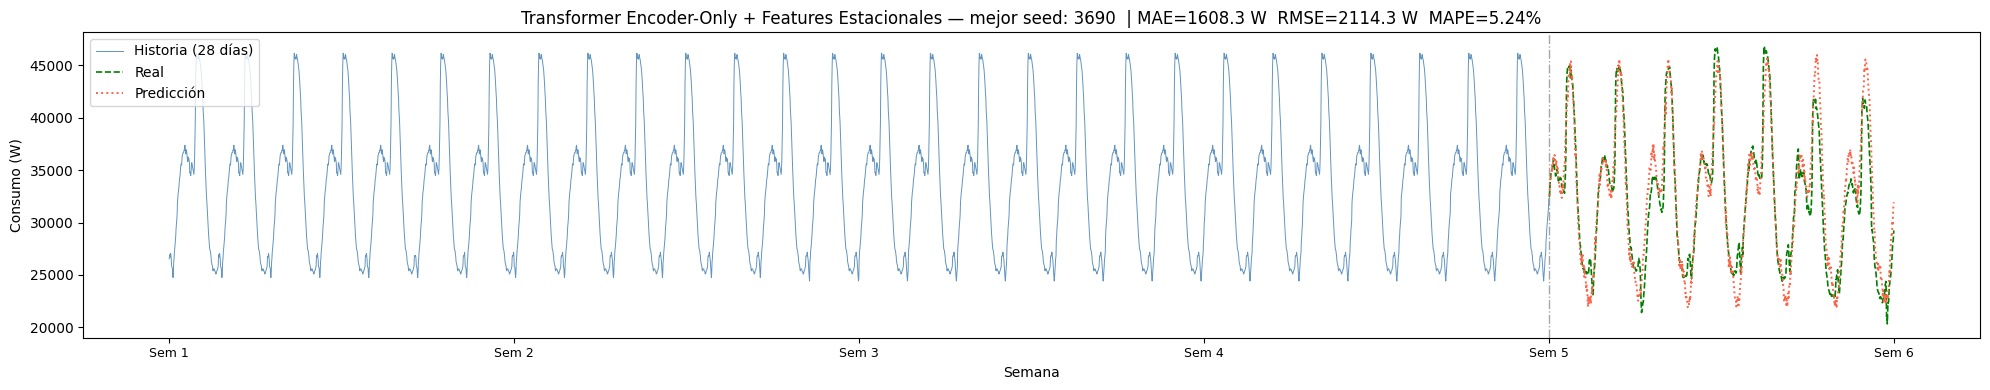

In [7]:
def enable_dropout(m):
    if isinstance(m, torch.nn.Dropout):
        m.train()

denorm = lambda v: v * (s_max - s_min) + s_min

STEPS_PER_DAY  = 144
STEPS_PER_WEEK = STEPS_PER_DAY * 7
MONTH_STEPS    = STEPS_PER_DAY * 28

# ── Historia ──────────────────────────────────────────────────────────────────
history_chunks = []
n_chunks = min(MONTH_STEPS // SEQ_LEN + 2, len(test_ds))
for i in range(n_chunks):
    xc, _ = test_ds[i]
    history_chunks.append(denorm(xc[:, 0].numpy()))

hist_full  = np.concatenate(history_chunks)[-MONTH_STEPS:]
x_test, y_test = test_ds[n_chunks - 1]
y_true_raw = denorm(y_test.squeeze().numpy())

# ── Inferencia MC-Dropout con seed fija ───────────────────────────────────────
torch.manual_seed(4805)
np.random.seed(4805)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
model.apply(enable_dropout)

with torch.no_grad():
    preds = np.stack([
        model(x_test.unsqueeze(0)).squeeze().numpy()
        for _ in range(N_SAMPLES_MC)
    ])

preds_denorm = denorm(preds)
y_pred_raw   = preds_denorm.mean(axis=0)

mae  = np.mean(np.abs(y_true_raw - y_pred_raw))
rmse = np.sqrt(np.mean((y_true_raw - y_pred_raw) ** 2))
mape = np.mean(np.abs((y_true_raw - y_pred_raw) / (y_true_raw + 1e-8))) * 100
print(f"MAE={mae:.1f} W | RMSE={rmse:.1f} W | MAPE={mape:.2f}%")

# ── Ejes temporales ───────────────────────────────────────────────────────────
actual_hist = len(hist_full)
t_hist = np.arange(0, actual_hist)
t_pred = np.arange(actual_hist, actual_hist + PRED_LEN)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(t_hist, hist_full,  color="steelblue", label="Historia (28 días)", lw=0.7, alpha=0.85, zorder=2)
ax.plot(t_pred, y_true_raw, color="green",  linestyle="--", label="Real",       lw=1.2, zorder=3)
ax.plot(t_pred, y_pred_raw, color="tomato", linestyle=":",  label="Predicción", lw=1.4, zorder=4)
ax.axvline(actual_hist, color="gray", lw=1.0, alpha=0.7, linestyle="-.")

week_ticks = np.arange(0, actual_hist + PRED_LEN + 1, STEPS_PER_WEEK)
ax.set_xticks(week_ticks)
ax.set_xticklabels([f"Sem {i+1}" for i in range(len(week_ticks))], fontsize=9)

ax.set_xlabel("Semana")
ax.set_ylabel("Consumo (W)")
ax.set_title(
    f"Transformer Encoder-Only + Features Estacionales — mejor seed: 3690  "
    f"| MAE={mae:.1f} W  RMSE={rmse:.1f} W  MAPE={mape:.2f}%"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("forecast_estacional.png", dpi=150)
plt.show()

## 8. Diagnóstico de residuos

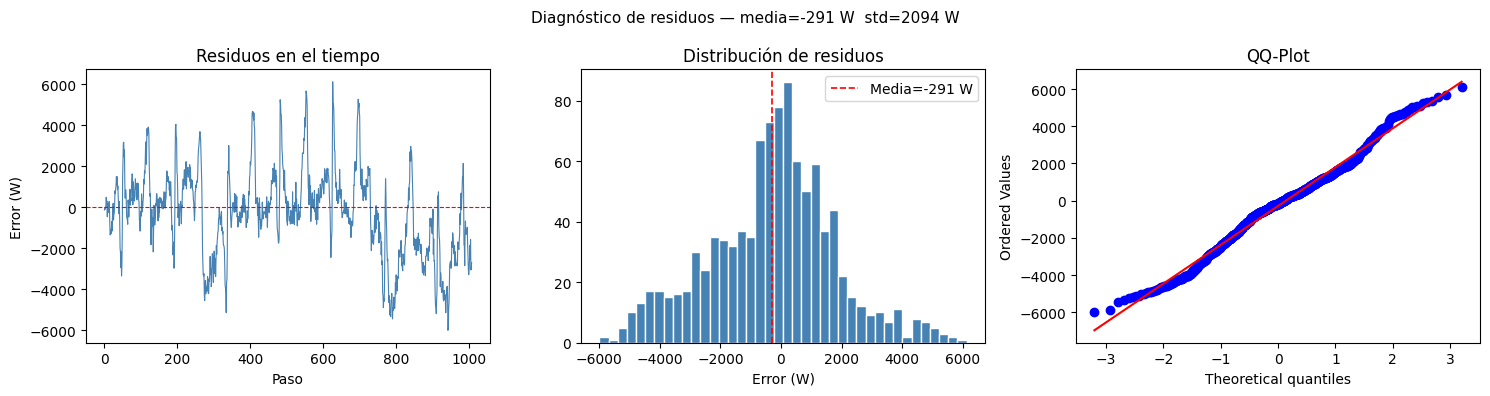

Media de residuos: -290.7 W  (ideal → 0)
Std  de residuos: 2094.2 W


In [8]:
residuals = y_true_raw - y_pred_raw

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuos en el tiempo
axes[0].plot(residuals, color="steelblue", lw=0.8)
axes[0].axhline(0, color="red", lw=0.8, linestyle="--")
axes[0].set_title("Residuos en el tiempo")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Error (W)")

# 2. Histograma de residuos
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(residuals.mean(), color="red", lw=1.2, linestyle="--",
                label=f"Media={residuals.mean():.0f} W")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Error (W)")
axes[1].legend()

# 3. QQ-plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot")

plt.suptitle(
    f"Diagnóstico de residuos — media={residuals.mean():.0f} W  std={residuals.std():.0f} W",
    fontsize=11
)
plt.tight_layout()
plt.savefig("diagnostics_estacional.png", dpi=150)
plt.show()

print(f"Media de residuos: {residuals.mean():.1f} W  (ideal → 0)")
print(f"Std  de residuos: {residuals.std():.1f} W")